1. Data Quality Overview
Total rows: 36,514
Total columns: 30

Missing Values:


Series([], dtype: int64)


2. Target Variables Distribution

Procedure Acceptance Rate:


target_accepted
1    0.591472
0    0.408528
Name: proportion, dtype: float64


Payment within 30 days Rate:


target_paid_30d
0    0.752807
1    0.247193
Name: proportion, dtype: float64

c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

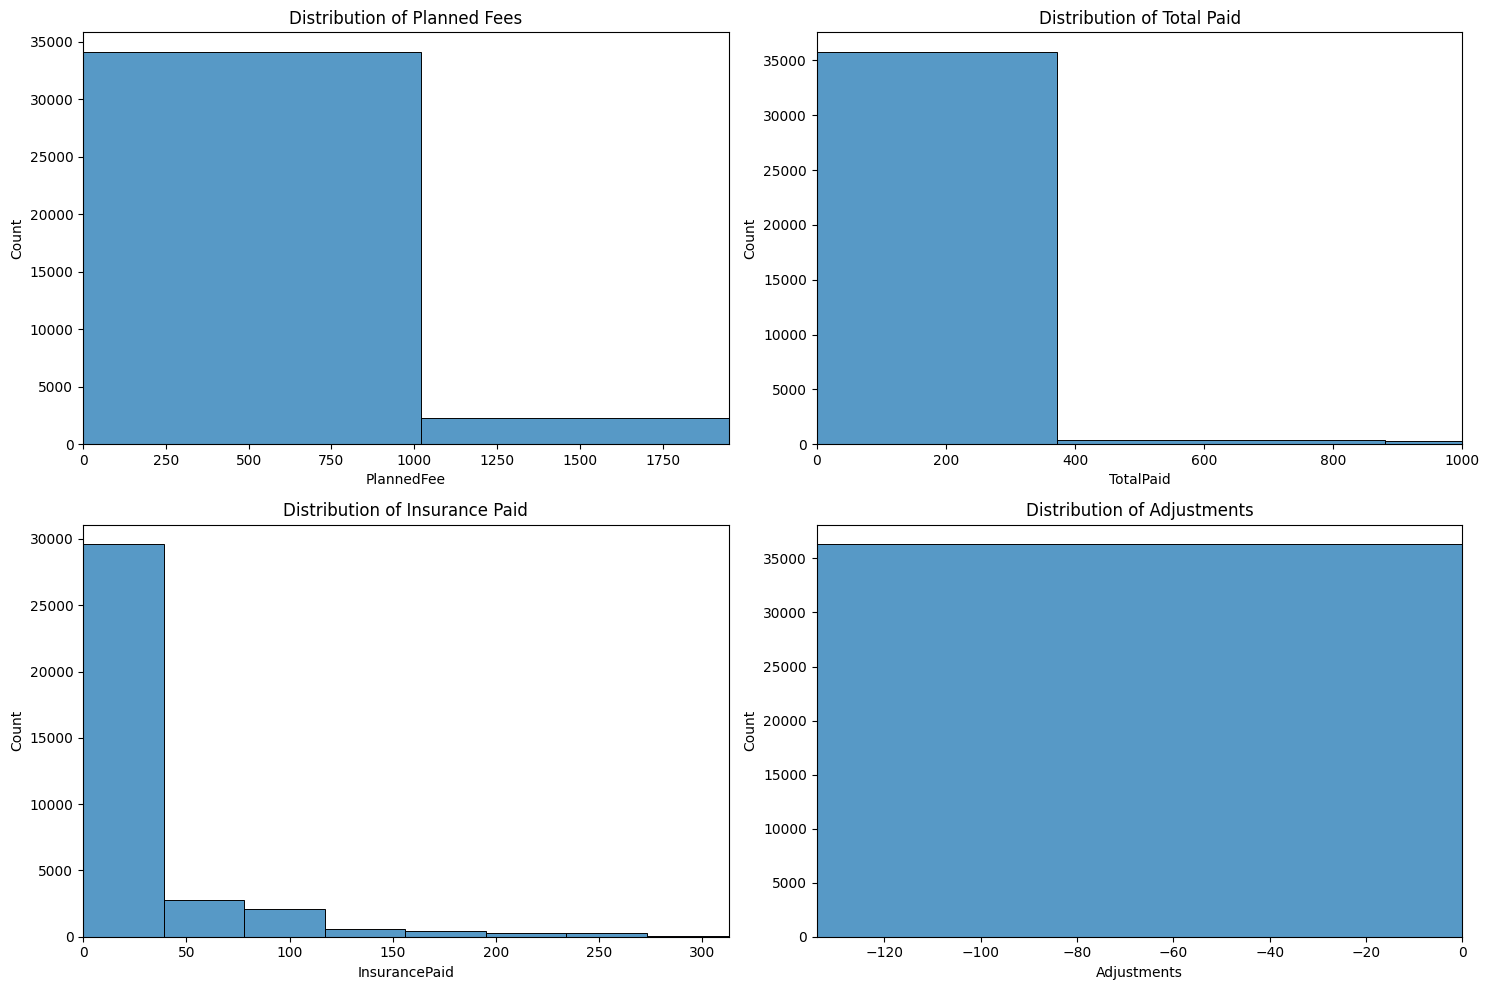


Financial Metrics Summary (excluding outliers):

PlannedFee:
Median: $76.00
IQR: $165.00
95th percentile: $1,288.00

TotalPaid:
Median: $0.00
IQR: $15.20
95th percentile: $192.43

InsurancePaid:
Median: $0.00
IQR: $0.00
95th percentile: $132.00

Adjustments:
Median: $0.00
IQR: $0.00
95th percentile: $0.00


c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


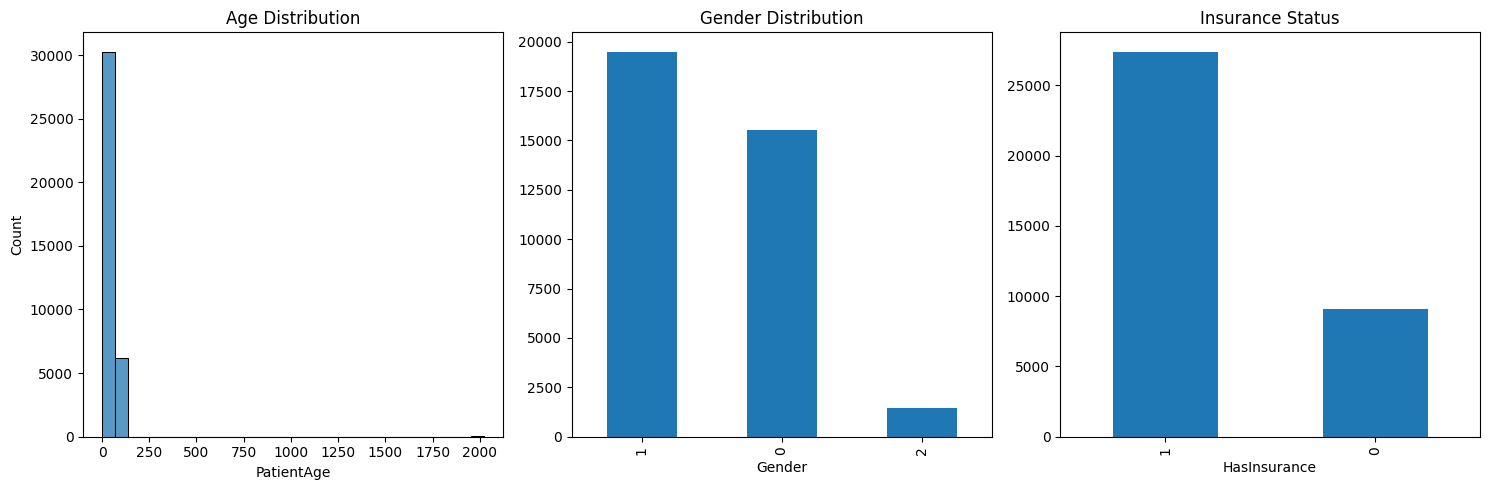

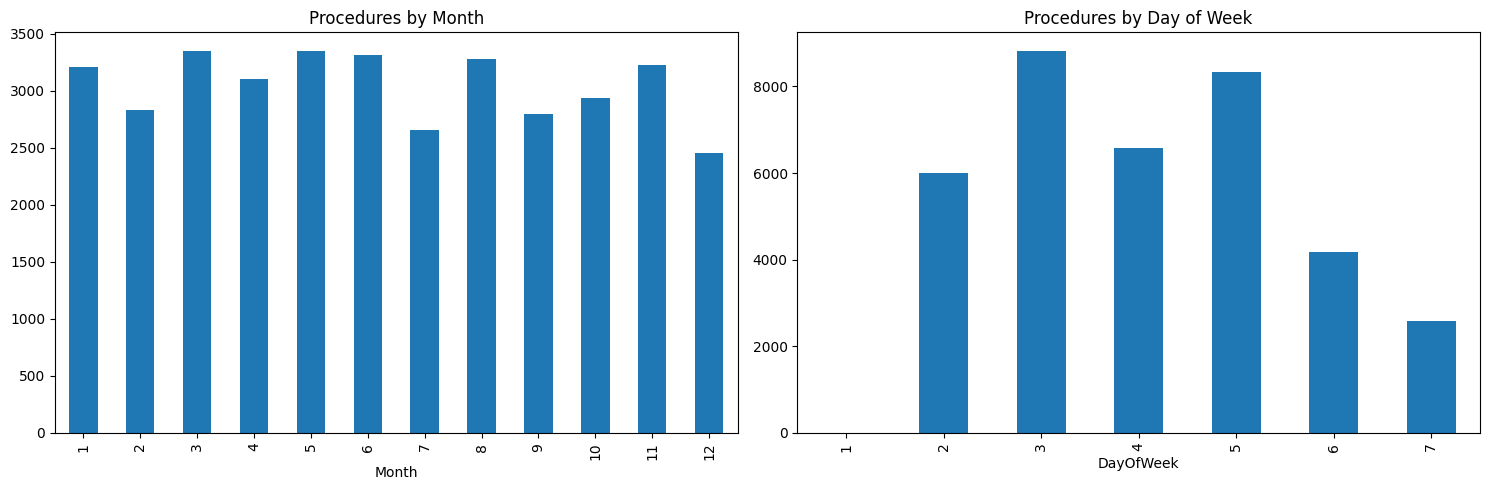


6. Financial Summary Statistics


,PlannedFee,TotalPaid,InsurancePaid,Adjustments,Balance_0_30_Days,Balance_31_60_Days,Balance_61_90_Days,Balance_Over_90_Days
count,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000,36514.000000
mean,219.515415,43.436409,27.527553,-11.959816,31.592128,8.994014,3.158124,31.786947
std,682.950420,224.354671,89.253518,263.939918,251.953674,71.982027,41.595323,182.824724
min,0.000000,-136.000000,0.000000,-27680.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,196.000000,15.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,51000.000000,25248.400000,1950.000000,256.000000,7101.600000,1292.800000,1306.400000,3113.000000


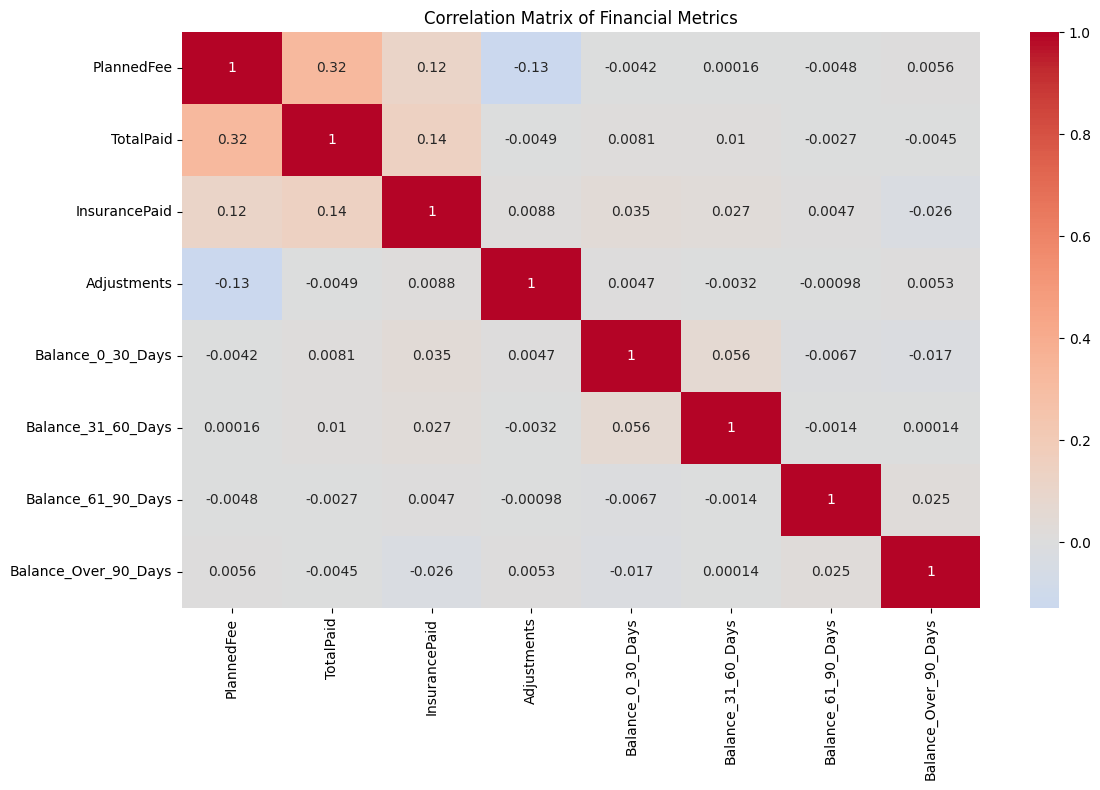


8. Procedure Categories


ProcCat
73     12069
250     6558
74      6436
81      2407
82      2346
75      2096
80      1723
77      1329
78       402
85       373
622      272
76       212
83        92
251       83
79        71
540       41
301        4
Name: count, dtype: int64


Treatment Areas:


TreatArea
0    15510
2     9434
3     7321
1     2136
7     1494
6      390
4      227
5        2
Name: count, dtype: int64


Multi-Visit Procedures:


IsMultiVisit
0    1.0
Name: proportion, dtype: float64

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Read the parquet file
df = pd.read_parquet('../data/processed/treatment_journey_opendental_analytics_opendentalbackup_01_03_2025.parquet')


# 1. Basic Data Quality Checks
print("1. Data Quality Overview")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")
print("\nMissing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Target Variable Distribution
print("\n2. Target Variables Distribution")
print("\nProcedure Acceptance Rate:")
display(df['target_accepted'].value_counts(normalize=True))
print("\nPayment within 30 days Rate:")
display(df['target_paid_30d'].value_counts(normalize=True))

# 3. Key Metrics Distribution with adjusted scales
plt.figure(figsize=(15, 10))

# Planned Fees
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='PlannedFee', bins=50)
plt.title('Distribution of Planned Fees')
plt.xlim(0, df['PlannedFee'].quantile(0.99))  # Limit to 99th percentile

# Total Paid
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='TotalPaid', bins=50)
plt.title('Distribution of Total Paid')
plt.xlim(0, df['TotalPaid'].quantile(0.99))

# Insurance Paid
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='InsurancePaid', bins=50)
plt.title('Distribution of Insurance Paid')
plt.xlim(0, df['InsurancePaid'].quantile(0.99))

# Adjustments
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Adjustments', bins=50)
plt.title('Distribution of Adjustments')
plt.xlim(df['Adjustments'].quantile(0.01), df['Adjustments'].quantile(0.99))  # Handle negative values

plt.tight_layout()
plt.show()

# Print summary statistics for these metrics
print("\nFinancial Metrics Summary (excluding outliers):")
financial_cols = ['PlannedFee', 'TotalPaid', 'InsurancePaid', 'Adjustments']
for col in financial_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    median = df[col].median()
    print(f"\n{col}:")
    print(f"Median: ${median:,.2f}")
    print(f"IQR: ${q3-q1:,.2f}")
    print(f"95th percentile: ${df[col].quantile(0.95):,.2f}")

# 4. Patient Demographics
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='PatientAge', bins=30)
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')

plt.subplot(1, 3, 3)
df['HasInsurance'].value_counts().plot(kind='bar')
plt.title('Insurance Status')
plt.tight_layout()
plt.show()

# 5. Temporal Analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
df.groupby('Month')['ProcNum'].count().plot(kind='bar')
plt.title('Procedures by Month')

plt.subplot(1, 2, 2)
df.groupby('DayOfWeek')['ProcNum'].count().plot(kind='bar')
plt.title('Procedures by Day of Week')
plt.tight_layout()
plt.show()

# 6. Financial Metrics
print("\n6. Financial Summary Statistics")
financial_cols = ['PlannedFee', 'TotalPaid', 'InsurancePaid', 'Adjustments', 
                 'Balance_0_30_Days', 'Balance_31_60_Days', 'Balance_61_90_Days', 'Balance_Over_90_Days']
display(df[financial_cols].describe())

# 7. Correlation Analysis
plt.figure(figsize=(12, 8))
correlation_matrix = df[financial_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Financial Metrics')
plt.tight_layout()
plt.show()

# 8. Procedure Characteristics
print("\n8. Procedure Categories")
display(df['ProcCat'].value_counts())
print("\nTreatment Areas:")
display(df['TreatArea'].value_counts())
print("\nMulti-Visit Procedures:")
display(df['IsMultiVisit'].value_counts(normalize=True))

In [8]:
# Check age outliers
print("Age Statistics:")
print(df['PatientAge'].describe())

print("\nPatients with unusual ages (>100):")
age_outliers = df[df['PatientAge'] > 100][['PatientAge', 'PatNum', 'ProcDate', 'Gender']]
display(age_outliers)

# Check the original birthdate calculation
print("\nSample of raw dates for outliers:")
outlier_patients = df[df['PatientAge'] > 100]['PatNum'].unique()
query = """
SELECT 
    PatNum,
    Birthdate,
    ProcDate,
    TIMESTAMPDIFF(YEAR, Birthdate, ProcDate) as CalcAge
FROM procedurelog proc
JOIN patient pat ON proc.PatNum = pat.PatNum
WHERE proc.PatNum IN ({})
""".format(','.join(map(str, outlier_patients)))

# Execute this query against your database to see the raw dates
# Or examine a few specific rows in the original data

Age Statistics:
count    36514.000000
mean        49.565208
std         63.634904
min          1.000000
25%         31.000000
50%         50.000000
75%         64.000000
max       2022.000000
Name: PatientAge, dtype: float64

Patients with unusual ages (>100):


,PatientAge,PatNum,ProcDate,Gender
2506,2022,31593,2023-11-30,2
2569,2022,31593,2023-11-30,2
2682,2022,31593,2023-11-30,2
2683,2022,31593,2023-11-30,2
3121,2022,31504,2023-11-27,2
3122,2022,31504,2023-11-27,2
3123,2022,31504,2023-11-27,2
3124,2022,31504,2023-11-27,2
3125,2022,31504,2023-11-27,2
3175,2022,31504,2023-11-24,2



Sample of raw dates for outliers:


In [7]:
# Clean PatientAge column by filling missing values with -1
df['PatientAge'] = df['PatientAge'].fillna(-1)  # or another sentinel value

In [10]:
# Analyze PlannedFee distribution
print("PlannedFee Statistics:")
print(df['PlannedFee'].describe())

# Check for zeros and nulls
print("\nZero fees:")
print(f"Count: {(df['PlannedFee'] == 0).sum()}")
print(f"Percentage: {(df['PlannedFee'] == 0).mean()*100:.2f}%")

print("\nNull fees:")
print(f"Count: {df['PlannedFee'].isnull().sum()}")
print(f"Percentage: {df['PlannedFee'].isnull().mean()*100:.2f}%")

# Look at fees by procedure category
print("\nMedian fees by procedure category:")
display(df.groupby('ProcCat')['PlannedFee'].agg(['median', 'count', 'mean']).sort_values('count', ascending=False))

# Compare PlannedFee to actual payments
print("\nComparison with actual payments:")
payment_comparison = df[['PlannedFee', 'TotalPaid', 'InsurancePaid', 'Adjustments']].describe()
display(payment_comparison)

PlannedFee Statistics:
count    36514.000000
mean       219.515415
std        682.950420
min          0.000000
25%         31.000000
50%         76.000000
75%        196.000000
max      51000.000000
Name: PlannedFee, dtype: float64

Zero fees:
Count: 7076
Percentage: 19.38%

Null fees:
Count: 0
Percentage: 0.00%

Median fees by procedure category:


,median,count,mean
ProcCat,,,
73,76.0,12069,80.540641
250,0.0,6558,39.044404
74,109.0,6436,75.817161
81,1288.0,2407,878.042044
82,330.0,2346,277.636402
75,330.0,2096,307.750000
80,530.0,1723,1113.817179
77,157.0,1329,178.041384
78,736.5,402,1136.497512



Comparison with actual payments:


,PlannedFee,TotalPaid,InsurancePaid,Adjustments
count,36514.000000,36514.000000,36514.000000,36514.000000
mean,219.515415,43.436409,27.527553,-11.959816
std,682.950420,224.354671,89.253518,263.939918
min,0.000000,-136.000000,0.000000,-27680.000000
25%,31.000000,0.000000,0.000000,0.000000
50%,76.000000,0.000000,0.000000,0.000000
75%,196.000000,15.200000,0.000000,0.000000
max,51000.000000,25248.400000,1950.000000,256.000000


PlannedFee Statistics:
count    36514.000000
mean       219.515415
std        682.950420
min          0.000000
25%         31.000000
50%         76.000000
75%        196.000000
max      51000.000000
Name: PlannedFee, dtype: float64

Zero fees:
Count: 7076
Percentage: 19.38%

Median fees by procedure category:


,median,count,mean
ProcCat,,,
73,76.0,12069,80.540641
250,0.0,6558,39.044404
74,109.0,6436,75.817161
81,1288.0,2407,878.042044
82,330.0,2346,277.636402
75,330.0,2096,307.750000
80,530.0,1723,1113.817179
77,157.0,1329,178.041384
78,736.5,402,1136.497512



Top 10 highest fees:


,ProcNum,ProcCat,PlannedFee,TotalPaid,InsurancePaid
18495,1079111,250,51000.0,1000.0,0.0
3875,1081807,80,25500.0,0.0,0.0
14415,1084073,250,25500.0,25248.4,0.0
15328,1082862,80,25500.0,0.0,0.0
15329,1082861,78,25500.0,0.0,0.0
15907,1082331,80,25500.0,0.0,0.0
18340,1079110,250,25500.0,0.0,0.0
18341,1079109,250,25500.0,0.0,0.0
21070,1069885,80,25500.0,0.0,0.0
25750,1070019,80,25500.0,0.0,0.0


c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rains\anaconda3\envs\mdc_analytics_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


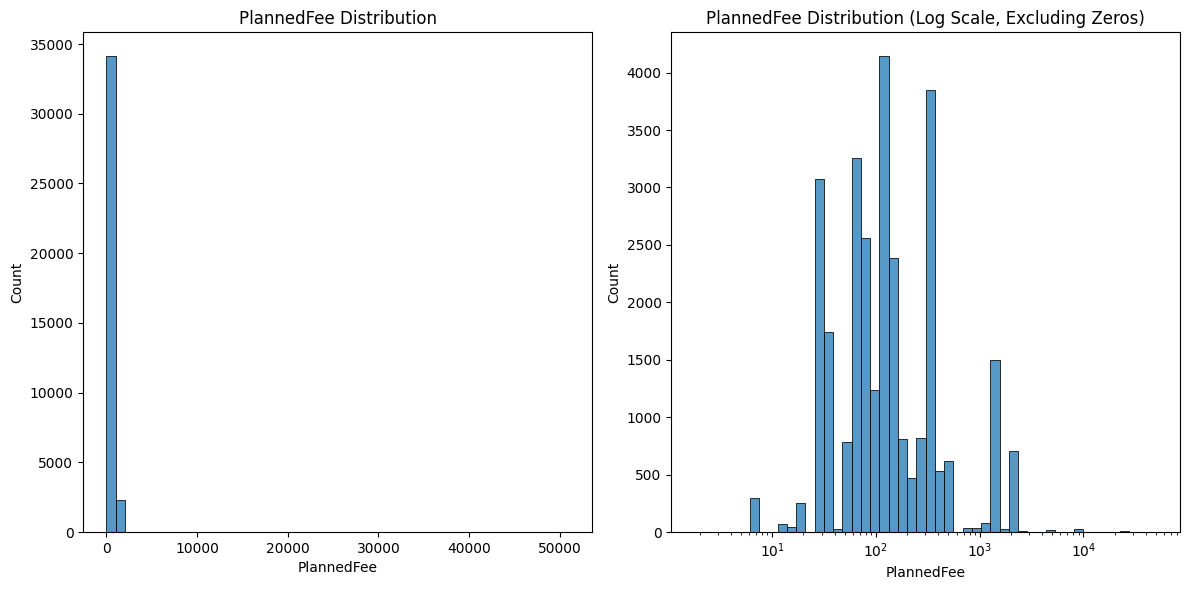

In [11]:
# Analyze PlannedFee distribution
print("PlannedFee Statistics:")
print(df['PlannedFee'].describe())

# Check for zeros and nulls
print("\nZero fees:")
print(f"Count: {(df['PlannedFee'] == 0).sum()}")
print(f"Percentage: {(df['PlannedFee'] == 0).mean()*100:.2f}%")

# Look at fees by procedure category
print("\nMedian fees by procedure category:")
display(df.groupby('ProcCat')['PlannedFee'].agg(['median', 'count', 'mean']).sort_values('count', ascending=False))

# Look at the highest fees
print("\nTop 10 highest fees:")
high_fees = df[['ProcNum', 'ProcCat', 'PlannedFee', 'TotalPaid', 'InsurancePaid']]
display(high_fees.nlargest(10, 'PlannedFee'))

# Distribution visualization with log scale
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='PlannedFee', bins=50)
plt.title('PlannedFee Distribution')

plt.subplot(1, 2, 2)
sns.histplot(data=df[df['PlannedFee'] > 0], x='PlannedFee', bins=50, log_scale=True)
plt.title('PlannedFee Distribution (Log Scale, Excluding Zeros)')

plt.tight_layout()
plt.show()